In [1]:
#Imports

%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../..')

import numpy as np
import src.viz_utils as viz_utils
import importlib
from src.utils import CanonPart, CanonPartMetadata, get_pointcloud_in_cam_frame, transform_cloud_to_base, remove_outliers, pos_quat_to_transform, project_3d_bounding_box
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation
from torchvision import transforms
from PIL import Image
import torch
from src.seg_utils import *
import open3d as o3d
import open3d.visualization.gui as gui
import copy as cp
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pytorch_lightning import seed_everything

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


pybullet build time: May 20 2022 19:45:31


In [2]:
#Load Segment Anything

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sam_checkpoint = '/home/rthomp12/ObjectPartSeg/sam_vit_h_4b8939.pth'  # Path to the SAM checkpoint
seg_model = load_sam(sam_checkpoint,device)

In [4]:
#Load the files and camera information
data_file = "/home/rthomp12/fewshot/scripts/experiment_notebooks/teapot_on_mug_20250114-151255/initial_scene.npy"
# data_file = '/home/rthomp12/fewshot/scripts/experiment_notebooks/blue_teapot_peep_mug_demo/initial_scene.npy'

# Load recorded demo transformation
transform_name = "/home/rthomp12/fewshot/scripts/experiment_notebooks/teapot_on_mug_20250114-151255/ee_transform.npz"
# transform_name = '/home/rthomp12/fewshot/scripts/experiment_notebooks/blue_teapot_peep_mug_demo/ee_transform.npz'
demo_transform = np.load(transform_name)

init_transform = pos_quat_to_transform(demo_transform['init_pos'],
                                             demo_transform['init_quat'])

# final_transform = pos_quat_to_transform(demo_transform['final_pos'],
#                                               demo_transform['final_quat'])

# ee_transform = np.matmul(final_transform, np.linalg.inv(init_transform))


initial_scene = np.load(data_file, allow_pickle=True).item()
camera_names = initial_scene['cam_names']
camera_names.remove('kevin') # Poor results so we exclude it 


print(f"Camera names: {camera_names}")

rgb_images = initial_scene['rgbs']
depth_images = initial_scene['depths']
intrinsics = initial_scene['intrinsic']
extrinsics = initial_scene['extrinsic']

Camera names: ['bob', 'stuart', 'dave', 'mel']


In [5]:
#Select the experiment type 

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~Mug v Rack
# parent_part_names = ['trunk', 'branch']
# child_part_names = ['cup', 'handle']


# parent_part_model_files = {'trunk': '/home/rthomp12/fewshot/part_based_warp_models/trunk_dict_20240412-042732', 
#                            'branch': '/home/rthomp12/fewshot/part_based_warp_models/branch_dict_20240412-042732'}

# child_part_model_files = {'cup': '/home/rthomp12/fewshot/part_based_warp_models/cup_dict_20240202-160637',
#                           'handle': '/home/rthomp12/fewshot/part_based_warp_models/handle_dict_20240202-160637'}

# #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~Teapot v Mug
parent_part_names = ['cup', 'handle']
child_part_names = ['body', 'tea_handle', 'spout', 'lid']

parent_part_model_files = {'cup': '/home/rthomp12/fewshot/mug_cup_20250103-220631_5',
                           'handle': '/home/rthomp12/fewshot/mug_handle_20250103-220631_5'}
child_part_model_files = {'body': '/home/rthomp12/fewshot/part_based_warp_models/body_dict_20241031-012841_5', 
                          'lid': '/home/rthomp12/fewshot/part_based_warp_models/lid_dict_20241031-012841_5',
                          'spout': '/home/rthomp12/fewshot/part_based_warp_models/spout_dict_20241031-012841_5',
                          'tea_handle': '/home/rthomp12/fewshot/part_based_warp_models/handle_dict_20241031-012841_5', }

parent_object = "mug"


# #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~ Mug v Watering Can
# parent_part_names = ['cup', 'handle']
# child_part_names = ['body', 'tea_handle', 'spout', ]

# parent_part_model_files = {'cup': '/home/rthomp12/fewshot/mug_cup_20250103-220631_5',
#                            'handle': '/home/rthomp12/fewshot/mug_handle_20250103-220631_5'}
# child_part_model_files = {'body': '/home/rthomp12/fewshot/part_based_warp_models/body_dict_20241031-012841_5', 
#                           'spout': '/home/rthomp12/fewshot/part_based_warp_models/spout_dict_20241031-012841_5',
#                           'tea_handle': '/home/rthomp12/fewshot/part_based_warp_models/handle_dict_20241031-012841_5', }

# parent_object = "mug"



# # Bowl v Mug

# parent_part_names = ['cup', 'handle']
# child_part_names = ['whole_bowl']

# parent_part_model_files = {'cup': '/home/rthomp12/fewshot/part_based_warp_models/cup_dict_20240202-160637',
#                           'handle': '/home/rthomp12/fewshot/part_based_warp_models/handle_dict_20240202-160637'}
# child_part_model_files = {'whole_bowl': '/home/rthomp12/fewshot/part_based_warp_models/whole_bowl_20240426-000022_10'}

#parent_object = "mug"

parent_part_models = {part: CanonPart.from_pickle(parent_part_model_files[part]) for part in parent_part_names}
child_part_models = {part: CanonPart.from_pickle(child_part_model_files[part]) for part in child_part_names}

all_part_names = parent_part_names + child_part_names

all_image_points = {camera_name: {part:[] for part in all_part_names} for camera_name in camera_names}
gripper_points = {camera_name: [] for camera_name in camera_names}

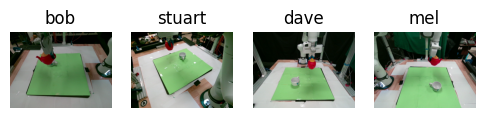

In [7]:
# Crop to gripper.
crops = {'child': {}, 'parent':{}}

# Use these as image[c[0]: c[1], c[2]: c[3]]
crop_coords = {'child': {}, 'parent':{}}
centroids = {'child': {}, 'parent':{}}
crop_size = 100

for name in camera_names:
    corners_2d, _ = project_3d_bounding_box(init_transform, extrinsics[name], intrinsics[name], 0.4)
    center = corners_2d[-1]
    # print(name, center)

    min_x, max_x = int(center[0] - crop_size), int(center[0] + crop_size)
    min_y, max_y = int(center[1] - crop_size), int(center[1] + crop_size)

    height, width, _ = rgb_images[name].shape
    min_x, max_x, min_y, max_y = crop_to_bounds(min_x, max_x, min_y, max_y, height, width)

    crop = rgb_images[name][min_y: max_y, min_x: max_x]

    crops['child'][name] = crop
    crop_coords['child'][name] = (min_y, max_y, min_x, max_x)
    centroids['child'][name] = center

    crops['child'][name] = rgb_images[name] # no crop rip
    crop_coords['child'][name] = (0, 0, rgb_images[name].shape[0], rgb_images[name].shape[1])#(min_y, max_y, min_x, max_x)
    centroids['child'][name] = center


scale = 3
plt.figure(figsize=(scale * len(crops), scale))
for i, crop in enumerate(crops['child'].keys()):
    # print(crop, crops['child'][crop].shape)
    plt.subplot(1, len(crops['child'].keys()), 1 + i)
    plt.title(crop)
    plt.imshow(crops['child'][crop])
    plt.axis("off")

In [8]:
from ultralytics import FastSAM
import cv2

# Define an inference source
# scale=5
# plt.figure(figsize=(scale * len(crops['parent']), scale))
# crop_size = 125
# Create a FastSAM model
#model = FastSAM("FastSAM-s.pt")  # or FastSAM-x.pt
# Run inference with texts prompt
for i, name in enumerate(camera_names):
    # source = rgb_images[name]

    # try:
    #     results = model(source, texts=parent_object)
    # except RuntimeError as e:
    #     print(f"Failed to detect target object in camera {name}.")
    #     continue

    # box = results[0].boxes[0]  # This plots the detections on the image

    # annotated_img = results[0].plot()

    # plt.subplot(1, len(camera_names), 1 + i)
    # plt.imshow(annotated_img)
    # x_center, y_center, width, height = box.xywhn[0]


    # center = (int(x_center*rgb_images[name].shape[1]), int(y_center*rgb_images[name].shape[0]))
    # min_x, max_x = int(center[0] - crop_size), int(center[0] + crop_size)
    # min_y, max_y = int(center[1] - crop_size), int(center[1] + crop_size)

    # height, width, _ = rgb_images[name].shape
    # min_x, max_x, min_y, max_y = crop_to_bounds(min_x, max_x, min_y, max_y, height, width)

    # crop = rgb_images[name][min_y: max_y, min_x: max_x]
    # print(crop.shape)

    crops['parent'][name] = rgb_images[name] # no crop rip
    crop_coords['parent'][name] = (0, 0, rgb_images[name].shape[0], rgb_images[name].shape[1])#(min_y, max_y, min_x, max_x)
    centroids['parent'][name] = center

# scale = 5
# plt.figure(figsize=(scale * len(crops), scale))
# for i, crop in enumerate(crops['parent'].keys()):
#     print(crop, crops['parent'][crop].shape)
#     plt.subplot(1, len(crops['parent'].keys()), 1 + i)
#     plt.imshow(crops['parent'][crop])
#     plt.axis("off")

In [12]:
#Segmentation GUI

part = None
camera_name = None
points = None
color = None
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'pink']


from ipywidgets import widgets 

def on_click(event):
    global color, cup_points, handle_points, points
    ix, iy = int(event.xdata), int(event.ydata)
    print(f"Coordinates: x={ix}, y={iy}")
    points.append([ix, iy])

    # Plot an 'X' marker at the clicked coordinates
    ax.plot(ix, iy, marker='x', markersize=10, color=color, zorder=2)
    fig.canvas.draw()  # Update the figure to show the new marker

def plot_map_with_points(part_names, images):
    global fig, ax, textbox, part, camera_name, points, color
    part = part_names[0]
    camera_name = camera_names[0]
    points = all_image_points[camera_name][part]
    color = 'red'

    buttons = widgets.RadioButtons(
        options=part_names + ['gripper'],
        disabled=False
    )
    
    display(buttons)

    def radio(value):
        global color, colors, points, all_image_points, camera_name
        part = value['new']
        if part == 'gripper':
            points = gripper_points[camera_name]
            color = colors[len(part_names)]
        else:
            points = all_image_points[camera_name][value['new']]
            color = colors[part_names.index(value['new'])]
        
        
    buttons.observe(radio, names = 'value')
    
    buttons2 = widgets.RadioButtons(
        options=camera_names,
        disabled=False
    )
    
    display(buttons2)
    def radio2(value):
        global points, all_image_points, rgb_images, camera_name, camera_names, part

        camera_name=value['new']
        part_points = all_image_points[camera_name]
        points = part_points[part]
        
        for p in part_names: 
            all_image_points[camera_name][p] = []
        gripper_points[camera_name] = []
        ax.imshow(images[camera_name], cmap=cmap, zorder=1)
        fig.canvas.draw()
        
    buttons2.observe(radio2, names='value')
    
    fig, ax = plt.subplots(figsize=(10, 10))
    cmap = matplotlib.colors.ListedColormap(['black', 'white'])
#     textbox = matplotlib.widgets.TextBox(ax, 'temp',)

    ax.imshow(images[camera_name], cmap=cmap, zorder=1)

    #plt.legend()
    plt.show()

    # Connect the click event
    cid = fig.canvas.mpl_connect('button_press_event', on_click)

RadioButtons(options=('body', 'tea_handle', 'spout', 'lid', 'gripper'), value='body')

RadioButtons(options=('bob', 'stuart', 'dave', 'mel'), value='bob')

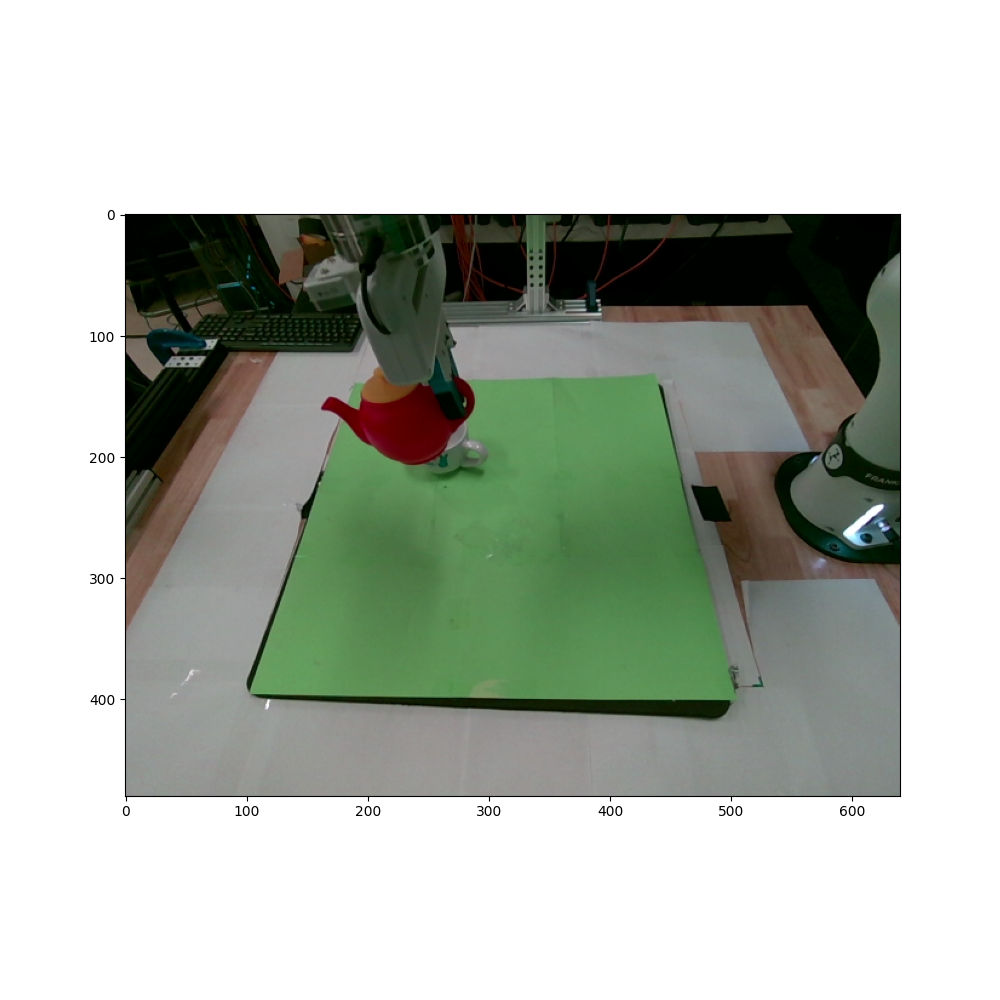

In [13]:
#Run the segmentation 

%matplotlib widget
plot_map_with_points(child_part_names, crops['child'])

RadioButtons(options=('cup', 'handle', 'gripper'), value='cup')

RadioButtons(options=('bob', 'stuart', 'dave', 'mel'), value='bob')

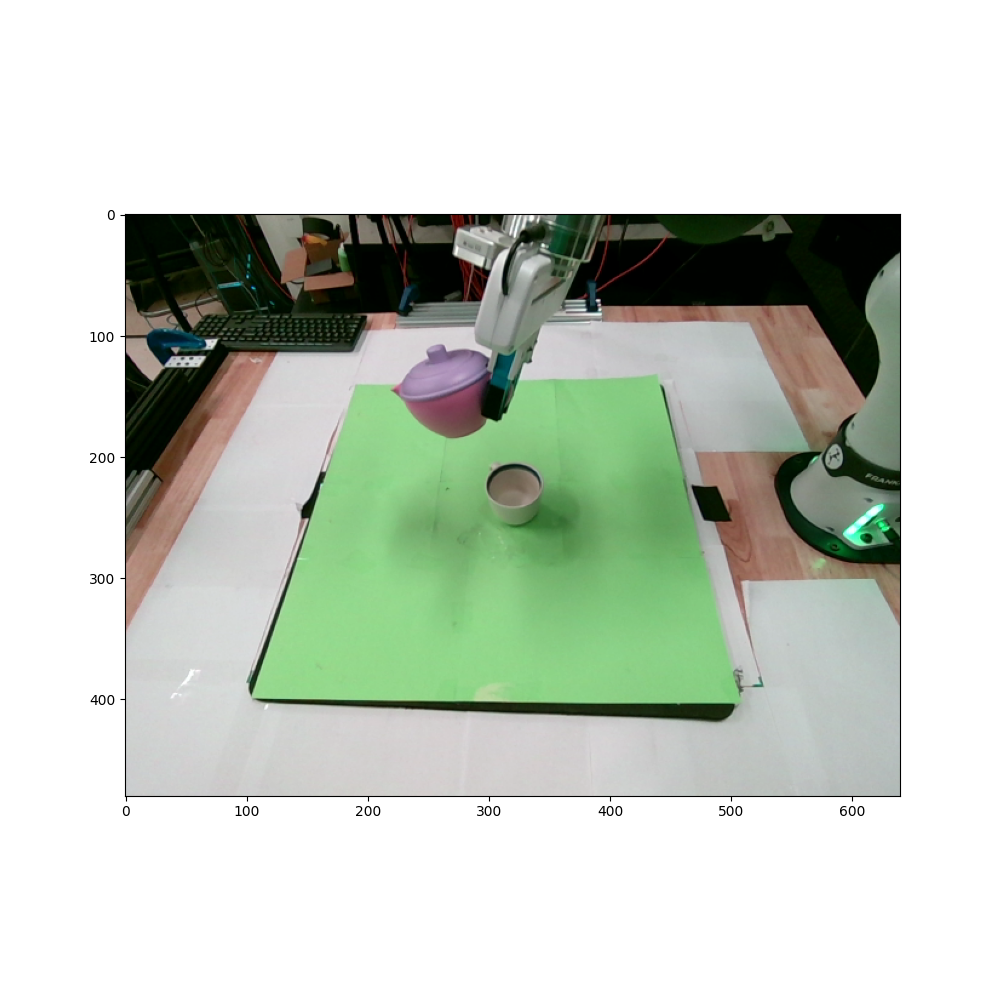

Coordinates: x=324, y=216
Coordinates: x=303, y=239
Coordinates: x=329, y=247
Coordinates: x=306, y=208
Coordinates: x=313, y=219
Coordinates: x=300, y=184
Coordinates: x=324, y=191
Coordinates: x=312, y=263
Coordinates: x=316, y=293
Coordinates: x=332, y=275
Coordinates: x=300, y=279
Coordinates: x=295, y=286
Coordinates: x=322, y=317
Coordinates: x=305, y=296
Coordinates: x=336, y=289
Coordinates: x=335, y=313
Coordinates: x=338, y=322


In [10]:

%matplotlib widget
plot_map_with_points(parent_part_names, crops['parent'])

In [11]:

mask_points, mask_labels, mask_masks, mask_scores, sam_embeddings = {},{},{},{},{}
for dict_starter in [mask_points, mask_labels, mask_masks, mask_scores, sam_embeddings]:
    dict_starter.update({name: {} for name in camera_names})

for camera in camera_names:
    for part in all_part_names:
        mask_points[camera][part] = np.array(all_image_points[camera][part])
        mask_labels[camera][part] = np.ones(mask_points[camera][part].shape[0], dtype=int)

for camera_name in camera_names:
    for obj in ['child', 'parent']:
        for masked_part in eval(f'{obj}_part_names'):
            seg_points = []
            seg_labels = []
            seg_points += list(mask_points[camera_name][masked_part])
            seg_labels += list(mask_labels[camera_name][masked_part])
            for other_part in eval(f'{obj}_part_names'):
                if masked_part == other_part:
                    continue
                seg_points += list(mask_points[camera_name][other_part])
                seg_labels += list(np.zeros(mask_points[camera_name][other_part].shape[0], dtype=int))
            
            if len(seg_points) == 0:
                mask_masks[camera_name][masked_part], mask_scores[camera_name][masked_part], sam_embeddings[camera_name][masked_part] = [], [], [],
            else:
                seg_points += list(np.array(gripper_points[camera_name]))
                seg_labels += list(np.zeros(np.array(gripper_points[camera_name]).shape[0], dtype=int))
                mask_masks[camera_name][masked_part], mask_scores[camera_name][masked_part], sam_embeddings[camera_name][masked_part] = segment(seg_model, 
                                                                                                         crops[obj][camera_name], 
                                                                                                         np.array(seg_points), 
                                                                                                         np.array(seg_labels), 
                                                                                                         multimask_flag=False)

In [12]:
for part in ["cup", "handle"]:
    for j, (mask, score) in enumerate(zip(mask_masks[demo_camera][part], mask_scores[demo_camera][part])):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,20))
        # plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        ax1.imshow(crops["child"][demo_camera])
        ax1.title.set_text(f"Mask {j+1}, Score: {score:.3f}")
        ax1.title.set_fontsize(40)
        show_mask(mask, ax1)
        show_points(mask_points[demo_camera][part], mask_labels[demo_camera][part], ax1)
        demo_img_mask = mask_masks[demo_camera][part][0]
        # print(demo_img_mask)
        ax2.imshow(demo_img_mask)
        ax2.title.set_text("Mask")
        ax2.title.set_fontsize(40)
        fig.tight_layout()

NameError: name 'demo_camera' is not defined

In [ ]:
plt.close() #close previous plots

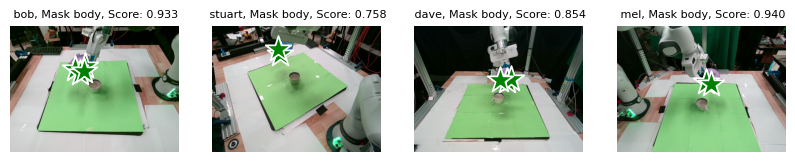

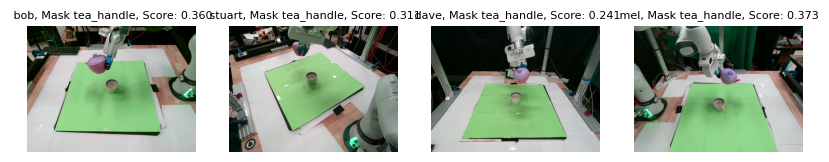

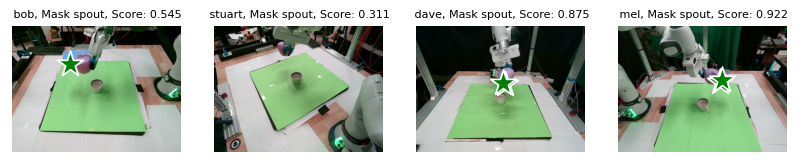

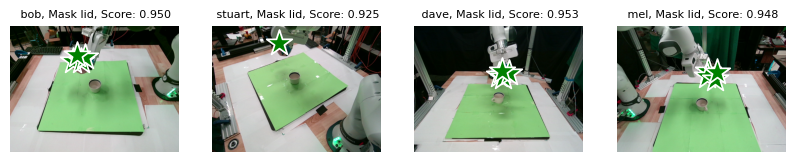

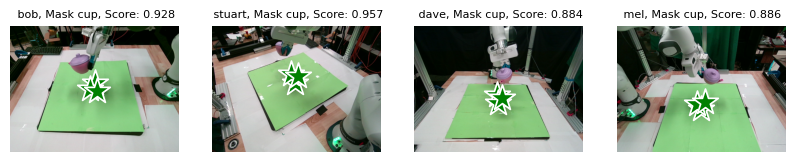

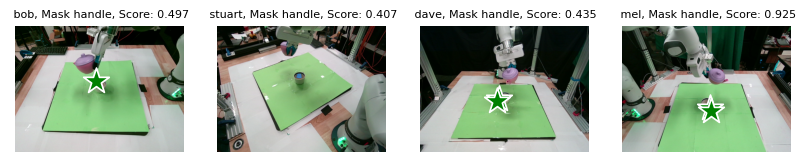

In [13]:
%matplotlib inline
## Visualize masks

for obj in ['child', 'parent']:
    for part in eval(f'{obj}_part_names'):
        scale = 5
        plt.figure(figsize=(scale * len(crops), scale))
        for i, camera_name in enumerate(camera_names):
            for j, (mask, score) in enumerate(zip(mask_masks[camera_name][part], mask_scores[camera_name][part])):
                plt.subplot(1, len(camera_names), 1 + i)
                plt.axis('off')
                plt.imshow(crops[obj][camera_name])
                show_mask(mask, plt.gca())
                plt.title(f" {camera_name}, Mask {part}, Score: {score:.3f}", fontsize=8)
                try:
                    show_points(mask_points[camera_name][part], mask_labels[camera_name][part], plt.gca())
                except IndexError: #handle is not visible in some views
                    continue
                
plt.show()


In [23]:
#PCL post-processing

pcls = {camera_name: get_pointcloud_in_cam_frame(rgb_images[camera_name],
                                                 depth_images[camera_name],
                                                intrinsics[camera_name]).reshape(depth_images[camera_name].shape[0], 
                                                                                 -1, 6) for camera_name in camera_names}
masked_pcls = {part:[] for part in all_part_names}
for camera_name in ['bob', 'dave', 'stuart', 'mel']: #kevin is cut out bc i'm seeing Bad reflection issues with it:#camera_names:
    for obj in ['child', 'parent']:
        for part in eval(f'{obj}_part_names'):
            if len(mask_masks[camera_name][part]) == 0:
                continue
            mask = np.zeros(pcls[camera_name].shape[:2], dtype=bool)
            min_y, max_y, min_x, max_x = crop_coords[obj][camera_name]
            if obj == "parent":
                mask = mask_masks[camera_name][part][0]
            else:
                # mask[min_y: max_y, min_x: max_x] = mask_masks[camera_name][part]
                mask = mask_masks[camera_name][part][0]
            cloud = pcls[camera_name][mask]
            if mask_scores[camera_name][part] > .7:
                masked_pcls[part].append(transform_cloud_to_base(cloud, extrinsics, camera_name))
    
for part in all_part_names:
    try:
        masked_pcls[part] = np.concatenate(masked_pcls[part])[:, :3]
        masked_pcls[part] = masked_pcls[part][masked_pcls[part][:,2] > .01]
        masked_pcls[part] = masked_pcls[part][masked_pcls[part][:,2] < .52]
        # masked_pcls[part] = masked_pcls[part][masked_pcls[part][:,1] > -.38]
        
        masked_pcls[part] = remove_outliers(masked_pcls[part], radius=.015)
    except ValueError:
        continue
masked_pcls['body'] = masked_pcls['body'][masked_pcls['body'][:,0] > .55]
masked_pcls['body'] = masked_pcls['body'][masked_pcls['body'][:,0] < .64]
masked_pcls['lid'] = masked_pcls['lid'][masked_pcls['lid'][:,0] > .55]
masked_pcls['lid'] = masked_pcls['lid'][masked_pcls['lid'][:,0] < .64]

Remove radius outliers: [========================================] 100%
Remove radius outliers: [========================================] 100%
Remove radius outliers: [========================================] 100%
Remove radius outliers: [========================================] 100%
Remove radius outliers: [========================================] 100%


In [24]:
#Visualize PCL
#print(masked_pcls)
camera = dict(
    eye=dict(x=1.2, y=-1.2, z=.2),
    center=dict(x=.8,y=.5,z=0)
)

#masked_pcls['body'] = masked_pcls['body'][masked_pcls['body'][:,0] > .53]
#masked_pcls['body'] = masked_pcls['body'][masked_pcls['body'][:,0] < .64]
viz_utils.show_pcds_plotly({k:v for k,v in masked_pcls.items() if len(v) != 0}, camera=camera
)

In [ ]:
#TODO: add vizualization of descriptors for easier debugging 

In [ ]:
# Visualize pcl by individual camera 
masked_pcls_by_camera = {camera_name:[] for camera_name in camera_names}
for camera_name in ['bob', 'stuart', 'mel', 'dave']: #kevin is cut out bc i'm seeing Bad reflection issues with it
    for part in all_part_names:
        if len(mask_masks[camera_name][part]) == 0:
            continue
        cloud = pcls[camera_name][mask_masks[camera_name][part][0]]
        if mask_scores[camera_name][part] > .7:
            masked_pcls_by_camera[camera_name].append(transform_cloud_to_base(cloud, extrinsics, camera_name))

for camera_name in camera_names:
    try:
        masked_pcls_by_camera[camera_name] = np.concatenate(masked_pcls_by_camera[camera_name])[:, :3]
        #masked_pcls_by_camera[camera_name] = masked_pcls_by_camera[camera_name][masked_pcls_by_camera[camera_name][:,2] > .01]
        masked_pcls_by_camera[camera_name] = masked_pcls_by_camera[camera_name][masked_pcls_by_camera[camera_name][:,2] < .5]
        masked_pcls_by_camera[camera_name] = masked_pcls_by_camera[camera_name][masked_pcls_by_camera[camera_name][:,1] > -.38]
        masked_pcls_by_camera[camera_name] = remove_outliers(masked_pcls_by_camera[camera_name])
    except ValueError:
        continue

camera = dict(
    eye=dict(x=1.2, y=-1.2, z=.2),
    center=dict(x=.8,y=.5,z=0)
)
viz_utils.show_pcds_plotly({k:v for k,v in masked_pcls_by_camera.items() if len(v) != 0}, camera=camera
)

In [ ]:
#Save PCLs
save_name = '/home/rthomp12/fewshot/scripts/experiment_notebooks/zz_parts_teapot_on_mug_test_20250115-054221_pink_teapot_small_mug/init_scene_pcls'
np.savez(save_name, **masked_pcls)

: 

# Getting Grasps

In [ ]:
#Get PCL Normals (for grasp selection)
masked_pcls = np.load(save_name + '.npz')

part = 'cup'
numpy_pcd = masked_pcls['cup']

# part = 'tea_handle'
# numpy_pcd = masked_pcls['tea_handle']

# part = 'bowl'
# numpy_pcd = masked_pcls['bowl']

pcd = o3d.geometry.PointCloud()

pcd.points = o3d.utility.Vector3dVector(numpy_pcd)
pcd.estimate_normals()
pcd = pcd.normalize_normals()

o3d.visualization.draw_geometries([pcd])


In [ ]:
#Import the grasping estimator

from src.GraspSelector import test

In [ ]:
#Visualize the predicted grasps

grasp_index = 0 # higher indices have a higher predicted cost/are less optimal

desired_grasp_poses = test(pcd,10)
import plotly.graph_objects as go
print(repr(desired_grasp_poses[grasp_index]))
data =  [
        go.Scatter3d(
            x=numpy_pcd[:, 0],
            y=numpy_pcd[:, 1],
            z=numpy_pcd[:, 2],
            marker={"size": 5, "color": numpy_pcd[:, 2], "colorscale": "Plotly3"},
            mode="markers",
            opacity=1.0,
        )
    ] + viz_utils.make_axis_plotly(desired_grasp_poses[grasp_index], .1)

fig = go.Figure(data=data)
fig.show()